# Human Resources EDA
- This notebook focus on practicing Python libraries such as pandas and numpy on an Exploratory Data Analysis environment.
- This notebook uses datasets from [Davide Polizzi Dataset on Kaggle](https://www.kaggle.com/datasets/davidepolizzi/hr-data-set-based-on-human-resources-data-set/data?select=tbl_Perf.csv)
- Because the focus is practicing Python, I will try to explain each steps

In [293]:
# Importing libraries
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

## 1. Data Exploration
- For a initial analysis we first must understand what the datasets have inside of them, such as columns names, the number of rows and columns (shape), and the datatypes of each column
- We must do this to all the datasets, after all, we are "curious" to know what they have
- We can "play" with them by generating grapsh with the focus of understanding one column or the relation of multiple columns
- During my first analysis, I was thinking that doing a Data Cleaning before proceeding with the analysis would be interesting, because of the type of some columns that impact the creation of graphs. 

### Exploring the dataset `tbl_Employee`

In [294]:
# Loading the csv to a variable and printing the 5 first rows
df_employee = pd.read_csv('datasets/tbl_Employee.csv')
df_employee.head(5)

,EmpID,EmpName,EngDt,TermDt,DepID,GenderID,RaceID,MgrID,DOB,PayRate,Level
0,1,"Nash, Kay K",01/01/2015,29/May/2017,8,1,1,1,12/Feb/1987,NaN,1
1,2,"Simpson, Raymond X",01/01/2015,NaN,7,0,4,2,15/Nov/1982,NaN,1
2,3,"Devlin, Kay M",06/10/2015,24/Jun/2019,10,1,5,3,22/Feb/1986,NaN,1
3,4,"Massie, Elisabeth V",01/01/2015,NaN,4,1,2,4,25/May/1977,NaN,1
4,5,"Mead, Catherine N",22/05/2015,15/Jul/2020,8,1,1,1,04/Apr/1995,NaN,2


In [295]:
# Printing the number ofr (rows, columns)
df_employee.shape

(1562, 11)

In [296]:
# Printing all the columns of the DataFrame
df_employee.columns

Index(['EmpID', 'EmpName', 'EngDt', 'TermDt', 'DepID', 'GenderID', 'RaceID',
       'MgrID', 'DOB', 'PayRate', 'Level'],
      dtype='str')

In [297]:
# Printing the type of each column from the DataFrame
df_employee.dtypes

EmpID         int64
EmpName         str
EngDt           str
TermDt          str
DepID         int64
GenderID      int64
RaceID        int64
MgrID         int64
DOB             str
PayRate     float64
Level         int64
dtype: object

In [298]:
# Printing the number of null values in each column
df_employee.isnull().sum()

EmpID          0
EmpName        0
EngDt          0
TermDt      1118
DepID          0
GenderID       0
RaceID         0
MgrID          0
DOB            0
PayRate     1562
Level          0
dtype: int64

In [299]:
# Printing the total of null values in the DataFrame
df_employee.isnull().sum().sum()

np.int64(2680)

### Exploring the dataset `tbl_Action`

In [300]:
# Loading the csv to a variable and printing the 5 first rows
df_action = pd.read_csv('datasets/tbl_Action.csv')
df_action.head(5)

,ActID,ActionID,EmpID,EffectiveDt
0,1,10,1,01/Jan/2015
1,2,10,2,01/Jan/2015
2,3,10,3,06/Oct/2015
3,4,10,4,01/Jan/2015
4,5,10,5,22/May/2015


In [301]:
# Printing the number of (rows, columns)
df_action.shape

(2586, 4)

In [302]:
# Printing all the columns of the DataFrame
df_action.columns

Index(['ActID', 'ActionID', 'EmpID', 'EffectiveDt'], dtype='str')

In [303]:
# Printing the type of each column from the DataFrame
df_action.dtypes

ActID          int64
ActionID       int64
EmpID          int64
EffectiveDt      str
dtype: object

In [304]:
# Printing the total of null values in the DataFrame
df_action.isnull().sum()

ActID          0
ActionID       0
EmpID          0
EffectiveDt    0
dtype: int64

In [305]:
# Printing the total of null values in the DataFrame
df_action.isnull().sum().sum()

np.int64(0)

### Exploring the dataset `tbl_Perf`

In [306]:
# Loading the csv to a variable and printing the 5 first rows
df_performance = pd.read_csv('datasets/tbl_Performance.csv')
df_performance

,PerfID,EmpID,Rating,PerfDate
0,1,1,1,31/Dec/2015
1,2,2,2,31/Dec/2015
2,3,3,2,31/Dec/2015
3,4,4,4,31/Dec/2015
4,5,5,2,31/Dec/2015
...,...,...,...,...
9600,9601,1558,3,31/Dec/2023
9601,9602,1559,2,31/Dec/2023
9602,9603,1560,4,31/Dec/2023
9603,9604,1561,2,31/Dec/2023


In [307]:
# Printing the number ofr (rows, columns)
df_performance.shape

(9605, 4)

In [308]:
# Printing all the columns of the DataFrame
df_performance.columns

Index(['PerfID', 'EmpID', 'Rating', 'PerfDate'], dtype='str')

In [309]:
# Printing the type of each column from the DataFrame
df_performance.dtypes

PerfID      int64
EmpID       int64
Rating      int64
PerfDate      str
dtype: object

In [310]:
# Printing the total of null values in the DataFrame
df_performance.isnull().sum()

PerfID      0
EmpID       0
Rating      0
PerfDate    0
dtype: int64

In [311]:
# Printing the total of null values in the DataFrame
df_performance.isnull().sum().sum()

np.int64(0)

## 2. Data Cleaning & Preparation

After analyzing the DataFrames, I identified several points that need to be addressed to ensure a high-quality analysis. Here are the planned steps:

1. **Column Renaming**: Some column names are not intuitive. I will rename them to be more descriptive and obvious, facilitating the learning process and code readability.
2. **Data Type Conversion**: Several columns containing date values are currently stored as strings. Converting these to `datetime` objects is fundamental for time-series analysis and plotting accurate graphs.
3. **Feature Engineering**: As a specific requirement for this project, I will split the full names of employees into two distinct columns: `First Name` and `Last Name`.
4. **Handling Missing Values**: I will identify and treat null values to prevent bias or errors in future calculations.
5. **Data Merging**: Finally, I will merge all relevant tables into a single master DataFrame. Consolidating employee data will allow for deeper insights and demonstrates the process of joining tables efficiently.

In [312]:
# First I will do changes on the tables
# The first step is to create a copy of each table, since we don't want to change the original DataFrames
df_employee_copy = df_employee.copy()
df_action_copy = df_action.copy()
df_performance_copy = df_performance.copy()

In [313]:
# Then i will start the changes on the employee copied DataFrame 
df_employee_copy.head(5)

,EmpID,EmpName,EngDt,TermDt,DepID,GenderID,RaceID,MgrID,DOB,PayRate,Level
0,1,"Nash, Kay K",01/01/2015,29/May/2017,8,1,1,1,12/Feb/1987,NaN,1
1,2,"Simpson, Raymond X",01/01/2015,NaN,7,0,4,2,15/Nov/1982,NaN,1
2,3,"Devlin, Kay M",06/10/2015,24/Jun/2019,10,1,5,3,22/Feb/1986,NaN,1
3,4,"Massie, Elisabeth V",01/01/2015,NaN,4,1,2,4,25/May/1977,NaN,1
4,5,"Mead, Catherine N",22/05/2015,15/Jul/2020,8,1,1,1,04/Apr/1995,NaN,2


In [314]:
# First I will separate the employee name in two separated columns
df_employee_copy[['last_name', 'first_name']] = df_employee_copy['EmpName'].str.split(',', expand=True)
df_employee_copy.head(5)

,EmpID,EmpName,EngDt,TermDt,DepID,GenderID,RaceID,MgrID,DOB,PayRate,Level,last_name,first_name
0,1,"Nash, Kay K",01/01/2015,29/May/2017,8,1,1,1,12/Feb/1987,NaN,1,Nash,Kay K
1,2,"Simpson, Raymond X",01/01/2015,NaN,7,0,4,2,15/Nov/1982,NaN,1,Simpson,Raymond X
2,3,"Devlin, Kay M",06/10/2015,24/Jun/2019,10,1,5,3,22/Feb/1986,NaN,1,Devlin,Kay M
3,4,"Massie, Elisabeth V",01/01/2015,NaN,4,1,2,4,25/May/1977,NaN,1,Massie,Elisabeth V
4,5,"Mead, Catherine N",22/05/2015,15/Jul/2020,8,1,1,1,04/Apr/1995,NaN,2,Mead,Catherine N


In [315]:
# Then let's convert the genderID to male and female
df_employee_copy['GenderID'] = df_employee_copy['GenderID'].map({1: 'Female', 0: 'Male'})
df_employee_copy.head(5)

,EmpID,EmpName,EngDt,TermDt,DepID,GenderID,RaceID,MgrID,DOB,PayRate,Level,last_name,first_name
0,1,"Nash, Kay K",01/01/2015,29/May/2017,8,Female,1,1,12/Feb/1987,NaN,1,Nash,Kay K
1,2,"Simpson, Raymond X",01/01/2015,NaN,7,Male,4,2,15/Nov/1982,NaN,1,Simpson,Raymond X
2,3,"Devlin, Kay M",06/10/2015,24/Jun/2019,10,Female,5,3,22/Feb/1986,NaN,1,Devlin,Kay M
3,4,"Massie, Elisabeth V",01/01/2015,NaN,4,Female,2,4,25/May/1977,NaN,1,Massie,Elisabeth V
4,5,"Mead, Catherine N",22/05/2015,15/Jul/2020,8,Female,1,1,04/Apr/1995,NaN,2,Mead,Catherine N


In [316]:
# For more convinience I will map each number from DeptID to an actual string with the department name
# Since we don't have any correspondence between number and department, this part will be created by me
mapping_dept = {
    1: 'Human Resources',
    2: 'IT',
    3: 'Sales',
    4: 'Marketing',
    5: 'Finance',
    6: 'Operations',
    7: 'Logistics',
    8: 'Legal',
    9: 'Customer Service',
    10: 'Engineering'
}
df_employee_copy['DepID'] = df_employee_copy['DepID'].map(mapping_dept)
df_employee_copy.head(5)

,EmpID,EmpName,EngDt,TermDt,DepID,GenderID,RaceID,MgrID,DOB,PayRate,Level,last_name,first_name
0,1,"Nash, Kay K",01/01/2015,29/May/2017,Legal,Female,1,1,12/Feb/1987,NaN,1,Nash,Kay K
1,2,"Simpson, Raymond X",01/01/2015,NaN,Logistics,Male,4,2,15/Nov/1982,NaN,1,Simpson,Raymond X
2,3,"Devlin, Kay M",06/10/2015,24/Jun/2019,Engineering,Female,5,3,22/Feb/1986,NaN,1,Devlin,Kay M
3,4,"Massie, Elisabeth V",01/01/2015,NaN,Marketing,Female,2,4,25/May/1977,NaN,1,Massie,Elisabeth V
4,5,"Mead, Catherine N",22/05/2015,15/Jul/2020,Legal,Female,1,1,04/Apr/1995,NaN,2,Mead,Catherine N


In [317]:
df_employee_copy.dtypes

EmpID           int64
EmpName           str
EngDt             str
TermDt            str
DepID             str
GenderID          str
RaceID          int64
MgrID           int64
DOB               str
PayRate       float64
Level           int64
last_name         str
first_name        str
dtype: object

In [318]:
# Now I will change the columns with date values from string to date type
df_employee_copy[['EngDt', 'TermDt', 'DOB']] = df_employee_copy[['EngDt', 'TermDt', 'DOB']].apply(pd.to_datetime, format='mixed', errors='coerce')
df_employee_copy.head(5)

,EmpID,EmpName,EngDt,TermDt,DepID,GenderID,RaceID,MgrID,DOB,PayRate,Level,last_name,first_name
0,1,"Nash, Kay K",2015-01-01,2017-05-29,Legal,Female,1,1,1987-02-12,NaN,1,Nash,Kay K
1,2,"Simpson, Raymond X",2015-01-01,NaT,Logistics,Male,4,2,1982-11-15,NaN,1,Simpson,Raymond X
2,3,"Devlin, Kay M",2015-06-10,2019-06-24,Engineering,Female,5,3,1986-02-22,NaN,1,Devlin,Kay M
3,4,"Massie, Elisabeth V",2015-01-01,NaT,Marketing,Female,2,4,1977-05-25,NaN,1,Massie,Elisabeth V
4,5,"Mead, Catherine N",2015-05-22,2020-07-15,Legal,Female,1,1,1995-04-04,NaN,2,Mead,Catherine N


In [319]:
# Now we have all the columns in the datetime format
df_employee_copy.dtypes

EmpID                  int64
EmpName                  str
EngDt         datetime64[us]
TermDt        datetime64[us]
DepID                    str
GenderID                 str
RaceID                 int64
MgrID                  int64
DOB           datetime64[us]
PayRate              float64
Level                  int64
last_name                str
first_name               str
dtype: object

In [320]:
# Now before I organize the columns in order, i will change the name of the columns to a more significant name
df_employee_copy = df_employee_copy.rename(columns={'EmpID': 'employeeID','EmpName': 'employee_name', 'EngDt': 'admission_date','TermDt': 'termination_date',
                                                   'DepID': 'departmentID', 'GenderID': 'gender', 'RaceID': 'raceID', 
                                                   'MgrID': 'managerID', 'DOB': 'date_of_birth', 'PayRate': 'payrate',
                                                   'Level': 'level'})
df_employee_copy

,employeeID,employee_name,admission_date,termination_date,departmentID,gender,raceID,managerID,date_of_birth,payrate,level,last_name,first_name
0,1,"Nash, Kay K",2015-01-01,2017-05-29,Legal,Female,1,1,1987-02-12,NaN,1,Nash,Kay K
1,2,"Simpson, Raymond X",2015-01-01,NaT,Logistics,Male,4,2,1982-11-15,NaN,1,Simpson,Raymond X
2,3,"Devlin, Kay M",2015-06-10,2019-06-24,Engineering,Female,5,3,1986-02-22,NaN,1,Devlin,Kay M
3,4,"Massie, Elisabeth V",2015-01-01,NaT,Marketing,Female,2,4,1977-05-25,NaN,1,Massie,Elisabeth V
4,5,"Mead, Catherine N",2015-05-22,2020-07-15,Legal,Female,1,1,1995-04-04,NaN,2,Mead,Catherine N
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1557,1558,"Shearer, Dimitrios Q",2023-01-11,NaT,Sales,Male,1,1526,1990-05-21,NaN,28,Shearer,Dimitrios Q
1558,1559,"Shute, Phyllis H",2023-12-07,NaT,Human Resources,Female,1,1460,1974-10-01,NaN,30,Shute,Phyllis H
1559,1560,"Scholes, Ripduman K",2023-04-22,NaT,Human Resources,Female,4,1559,1971-05-11,NaN,31,Scholes,Ripduman K
1560,1561,"Rawson, Elisabeth K",2023-07-03,NaT,Operations,Female,3,1554,1982-08-25,NaN,30,Rawson,Elisabeth K


In [321]:
# After changing the names I will order the columns, in this case I removed the column payrate, on this exercise
# the payrate did not have any value inside, only NaN values, so I decided to remove it, ina real world scenario
# probably the information was not loaded correctly, so in a real case it should be investigated, since payrate can provide
# valuable insights
df_employee_copy = df_employee_copy[[
    'employeeID', 
    'first_name', 
    'last_name', 
    'date_of_birth', 
    'gender', 
    'raceID',
    'admission_date', 
    'termination_date', 
    'departmentID', 
    'managerID', 
    'level'
]]
df_employee_copy.head()

,employeeID,first_name,last_name,date_of_birth,gender,raceID,admission_date,termination_date,departmentID,managerID,level
0,1,Kay K,Nash,1987-02-12,Female,1,2015-01-01,2017-05-29,Legal,1,1
1,2,Raymond X,Simpson,1982-11-15,Male,4,2015-01-01,NaT,Logistics,2,1
2,3,Kay M,Devlin,1986-02-22,Female,5,2015-06-10,2019-06-24,Engineering,3,1
3,4,Elisabeth V,Massie,1977-05-25,Female,2,2015-01-01,NaT,Marketing,4,1
4,5,Catherine N,Mead,1995-04-04,Female,1,2015-05-22,2020-07-15,Legal,1,2


In [322]:
# When I changed the gender from int to str i can "play" with the data in a graph format
# First I what to understand how is the ratio for man and woman
df_employee_copy.groupby('gender')['employeeID'].count()
gender_count = df_employee_copy['gender'].value_counts()

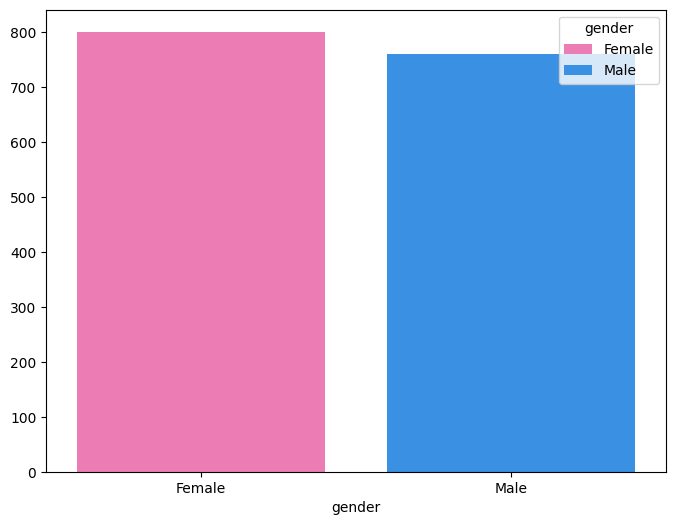

In [323]:
# When I changed the gender from int to str i can "play" with the data in a graph format
gender_count = df_employee_copy['gender'].value_counts()

plt.figure(figsize=(8, 6))
graph = sns.barplot(
    x=gender_count.index, 
    y=gender_count.values, 
    hue=gender_count.index,
    palette=['#FF69B4', '#1E90FF'], 
    legend=True
)
plt.show()

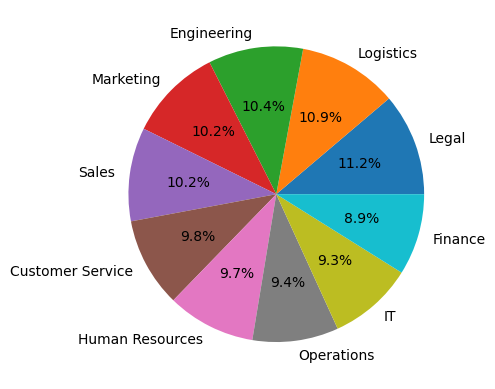

In [324]:
# In this case I wanted to plot the ratio of employees by department
df_employee_copy = df_employee_copy.rename(columns={'departmentID': 'departments'})
employee_by_department = df_employee_copy['departments'].value_counts()
labels = df_employee_copy['departments'].unique()
plt.pie(employee_by_department, labels=labels, autopct='%1.1f%%')
plt.show()

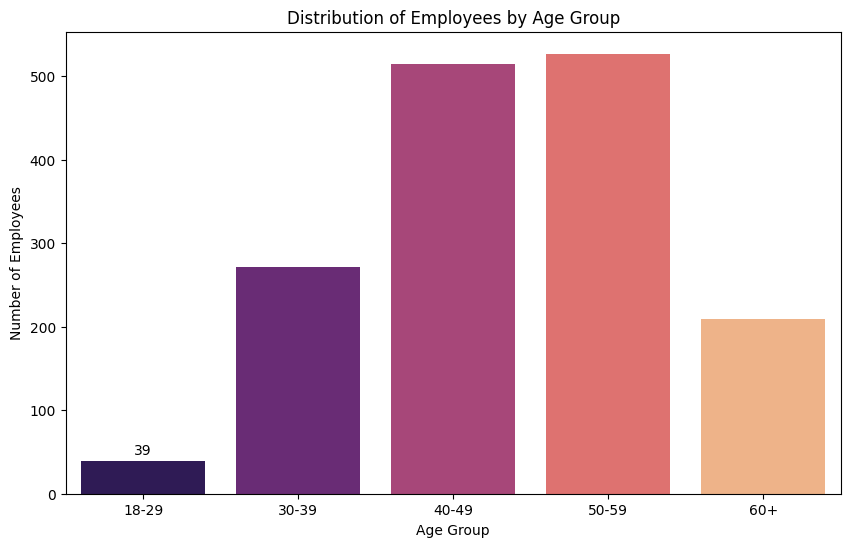

In [325]:
# On this cell I tried to create an age comparasion, to understand the major age group inside the company
from datetime import date
age = date.today().year - df_employee_copy['date_of_birth'].dt.year

bins = [18, 30, 40, 50, 60, 100]
labels = ['18-29', '30-39', '40-49', '50-59', '60+']
age_group = pd.cut(age, bins=bins, labels=labels) # This pandas method cut literally converts age to age range

age_dist = age_group.value_counts().reindex(labels)

plt.figure(figsize=(10, 6))
graph = sns.barplot(x=age_dist.index, y=age_dist.values, hue=age_dist.index, palette='magma', legend=False)
graph.bar_label(graph.containers[0], padding=3)

plt.title('Distribution of Employees by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Employees')
plt.show()

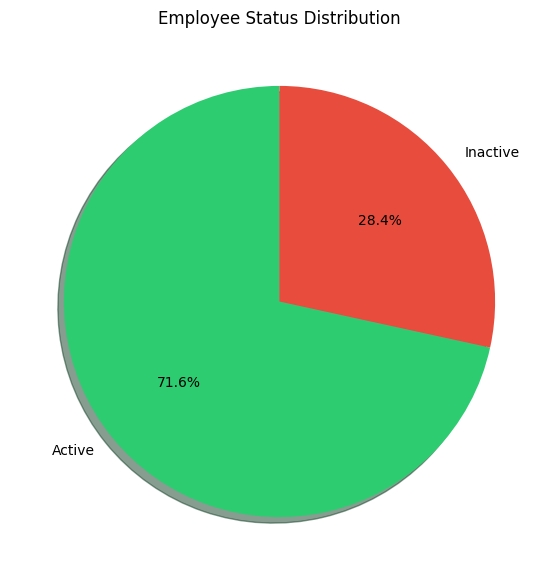

In [326]:
# Now let's see how many employees are actives and how many are not
status = np.where(df_employee_copy['termination_date'].isnull(), 'Active', 'Inactive')
status_counts = pd.Series(status).value_counts()

plt.figure(figsize=(7, 7))
plt.pie(
    status_counts.values, 
    labels=status_counts.index, 
    autopct='%1.1f%%',
    startangle=90,
    colors=['#2ECC71', '#E74C3C'],
    shadow=True
)

plt.title('Employee Status Distribution')
plt.show()

In [327]:
# Now I would llike to see the statistical data for this DataFrame
df_employee_copy.describe()

,employeeID,date_of_birth,raceID,admission_date,termination_date,managerID,level
count,1562.000000,1562,1562.000000,1562,444,1562.000000,1562.000000
mean,781.500000,1977-01-18 11:40:38.412291,3.010883,2016-12-31 18:55:46.478873,2020-05-10 05:50:16.216216,747.438540,14.574904
min,1.000000,1940-04-01 00:00:00,1.000000,2015-01-01 00:00:00,2015-01-31 00:00:00,1.000000,1.000000
25%,391.250000,1970-05-23 06:00:00,2.000000,2015-01-01 00:00:00,2018-08-16 00:00:00,346.000000,8.000000
50%,781.500000,1976-11-30 12:00:00,3.000000,2015-09-17 12:00:00,2020-07-30 12:00:00,753.000000,15.000000
75%,1171.750000,1983-11-29 00:00:00,4.000000,2018-04-06 18:00:00,2022-06-15 12:00:00,1137.000000,21.000000
max,1562.000000,2002-07-21 00:00:00,5.000000,2024-12-02 00:00:00,2024-02-10 00:00:00,1559.000000,31.000000
std,451.054875,NaN,1.417565,NaN,NaN,449.850843,7.634833


In [328]:
# Now we are goingo to the Action DataFrame
df_action_copy.head(4)

,ActID,ActionID,EmpID,EffectiveDt
0,1,10,1,01/Jan/2015
1,2,10,2,01/Jan/2015
2,3,10,3,06/Oct/2015
3,4,10,4,01/Jan/2015


In [329]:
# First as always we convert the date from string to datetime
df_action_copy['EffectiveDt'] = df_action_copy['EffectiveDt'].apply(pd.to_datetime, errors='coerce')
df_action_copy.head(5)

,ActID,ActionID,EmpID,EffectiveDt
0,1,10,1,2015-01-01
1,2,10,2,2015-01-01
2,3,10,3,2015-10-06
3,4,10,4,2015-01-01
4,5,10,5,2015-05-22


In [330]:
# After that, we change the columns names
df_action_copy = df_action_copy.rename(columns={
    'ActID': 'activityID',
    'ActionID': 'actionID',
    'EmpID': 'employeeID',
    'EffectiveDt': 'effective_date' 
})
df_action_copy

,activityID,actionID,employeeID,effective_date
0,1,10,1,2015-01-01
1,2,10,2,2015-01-01
2,3,10,3,2015-10-06
3,4,10,4,2015-01-01
4,5,10,5,2015-05-22
...,...,...,...,...
2581,2582,30,869,2023-05-16
2582,2583,30,1024,2023-08-17
2583,2584,30,1220,2023-08-10
2584,2585,30,1279,2023-03-24


In [331]:
# I want to find the unique 'actionID' values
df_action_copy['actionID'].unique()

array([10, 91, 90, 30])

In [332]:
# Then I use .groupby()  to understand how many actionID's we have on the DataFrame
df_action_copy.groupby('actionID')['actionID'].count()

actionID
10    1562
30     488
90     271
91     265
Name: actionID, dtype: int64

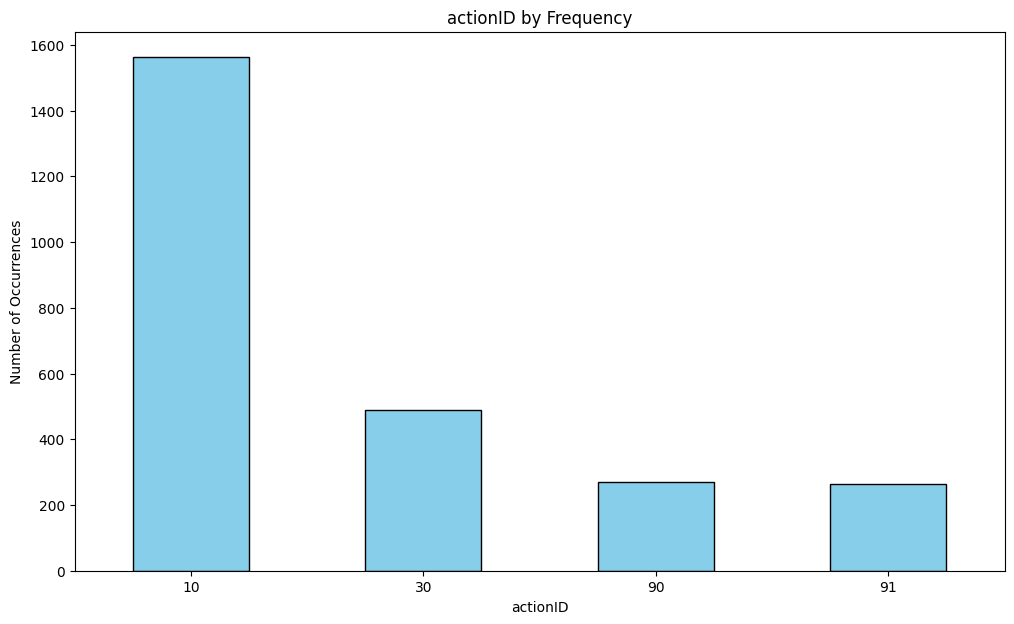

In [333]:
# Now I will create an bar chart to create a visualization of the difference
count = df_action_copy['actionID'].value_counts()

plt.figure(figsize=(12, 7))

count.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("actionID by Frequency")
plt.xlabel("actionID")
plt.ylabel("Number of Occurrences")
plt.xticks(rotation=0)

plt.show()

In [334]:
# I will use the .unique() on the activityID just to confirm if we have one for each row
df_action_copy.activityID.unique()

array([   1,    2,    3, ..., 2584, 2585, 2586], shape=(2586,))

In [335]:
df_action_copy.describe()

,activityID,actionID,employeeID,effective_date
count,2586.000000,2586.000000,2586.000000,2586
mean,1293.500000,30.458237,748.427688,2018-01-07 12:38:25.336427
min,1.000000,10.000000,1.000000,2015-01-01 00:00:00
25%,647.250000,10.000000,356.250000,2015-05-11 00:00:00
50%,1293.500000,10.000000,749.000000,2017-06-23 00:00:00
75%,1939.750000,30.000000,1128.750000,2020-04-19 18:00:00
max,2586.000000,91.000000,1562.000000,2024-02-12 00:00:00
std,746.658222,31.628416,436.647292,NaN


In [336]:
# Now let's work with the performance DataFrame
df_performance_copy.head(5)

,PerfID,EmpID,Rating,PerfDate
0,1,1,1,31/Dec/2015
1,2,2,2,31/Dec/2015
2,3,3,2,31/Dec/2015
3,4,4,4,31/Dec/2015
4,5,5,2,31/Dec/2015


In [337]:
df_performance_copy.dtypes

PerfID      int64
EmpID       int64
Rating      int64
PerfDate      str
dtype: object

In [338]:
# As always, let's transform the date column to the date type
df_performance_copy['PerfDate'] = df_performance_copy['PerfDate'].apply(pd.to_datetime, errors='coerce')
df_performance_copy

,PerfID,EmpID,Rating,PerfDate
0,1,1,1,2015-12-31
1,2,2,2,2015-12-31
2,3,3,2,2015-12-31
3,4,4,4,2015-12-31
4,5,5,2,2015-12-31
...,...,...,...,...
9600,9601,1558,3,2023-12-31
9601,9602,1559,2,2023-12-31
9602,9603,1560,4,2023-12-31
9603,9604,1561,2,2023-12-31


In [339]:
df_performance_copy = df_performance_copy.rename(columns={
    'PerfID': 'performanceID',
    'EmpID': 'employeeID',
    'Rating': 'rating',
    'PerfDate': 'performance_date'
})
df_performance_copy.head(5)

,performanceID,employeeID,rating,performance_date
0,1,1,1,2015-12-31
1,2,2,2,2015-12-31
2,3,3,2,2015-12-31
3,4,4,4,2015-12-31
4,5,5,2,2015-12-31


## 3. Bivariate Analysis
- Until now, most of the values were analyzed separatl
- Now we will compare values from the same DataFrame, to understand if they have a relation, based on our suspicions.
- For that we will merge our DataFrames

In [340]:
# First I will merge both the employees and actions DataFrames
df = pd.merge(df_employee_copy, df_action_copy, on='employeeID', how='left')
df.head(5)

,employeeID,first_name,last_name,date_of_birth,gender,raceID,admission_date,termination_date,departments,managerID,level,activityID,actionID,effective_date
0,1,Kay K,Nash,1987-02-12,Female,1,2015-01-01,2017-05-29,Legal,1,1,1,10,2015-01-01
1,1,Kay K,Nash,1987-02-12,Female,1,2015-01-01,2017-05-29,Legal,1,1,1209,91,2017-05-29
2,2,Raymond X,Simpson,1982-11-15,Male,4,2015-01-01,NaT,Logistics,2,1,2,10,2015-01-01
3,3,Kay M,Devlin,1986-02-22,Female,5,2015-06-10,2019-06-24,Engineering,3,1,3,10,2015-10-06
4,3,Kay M,Devlin,1986-02-22,Female,5,2015-06-10,2019-06-24,Engineering,3,1,1527,90,2019-06-24


In [341]:
# Then I will merge both the new DataFrame and performance DataFrame
df = pd.merge(df, df_performance_copy, on='employeeID', how='left')
df.head(5)

,employeeID,first_name,last_name,date_of_birth,gender,raceID,admission_date,termination_date,departments,managerID,level,activityID,actionID,effective_date,performanceID,rating,performance_date
0,1,Kay K,Nash,1987-02-12,Female,1,2015-01-01,2017-05-29,Legal,1,1,1,10,2015-01-01,1.0,1.0,2015-12-31
1,1,Kay K,Nash,1987-02-12,Female,1,2015-01-01,2017-05-29,Legal,1,1,1,10,2015-01-01,869.0,4.0,2016-12-31
2,1,Kay K,Nash,1987-02-12,Female,1,2015-01-01,2017-05-29,Legal,1,1,1209,91,2017-05-29,1.0,1.0,2015-12-31
3,1,Kay K,Nash,1987-02-12,Female,1,2015-01-01,2017-05-29,Legal,1,1,1209,91,2017-05-29,869.0,4.0,2016-12-31
4,2,Raymond X,Simpson,1982-11-15,Male,4,2015-01-01,NaT,Logistics,2,1,2,10,2015-01-01,2.0,2.0,2015-12-31


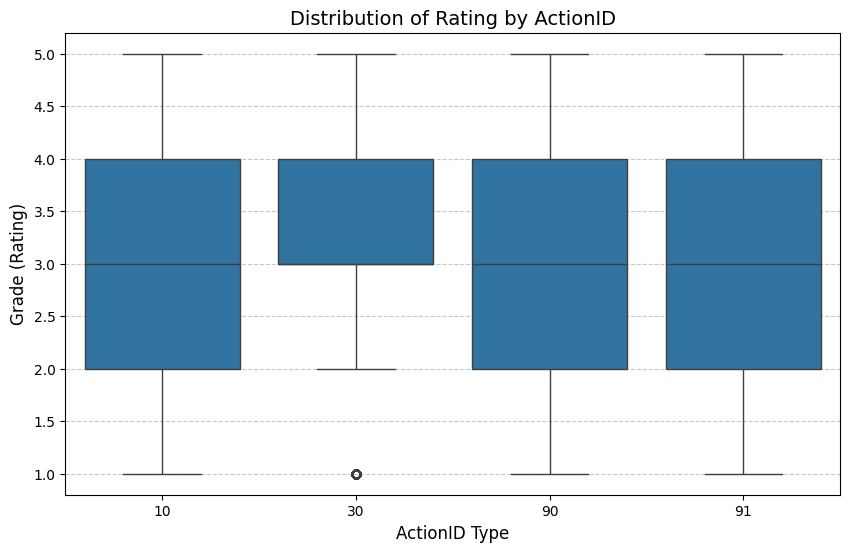

In [342]:
# Let's try to compare rating with actionID using a boxplot
plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x='actionID', y='rating')
plt.title('Distribution of Rating by ActionID', fontsize=14)
plt.xlabel('ActionID Type', fontsize=12)
plt.ylabel('Grade (Rating)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

As a first analysis we observe that the actionID 30 has a difference comparing with the others, not only that but we could identify an outlier with a rating of 1.0, in a real case this should be investigated.

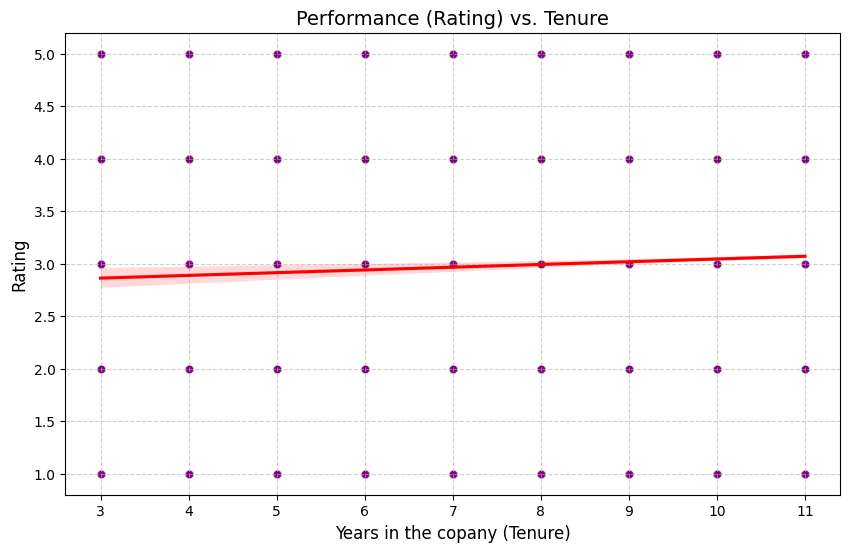

In [343]:
# Thinking about this outlier, let's understand first what kind of employees have the best performance, old or new
from datetime import date

plt.figure(figsize=(10, 6))

tenure = datetime.now().year - df['admission_date'].dt.year
sns.scatterplot(data=df, x=tenure, y='rating', alpha=0.5, color='purple')
sns.regplot(data=df, x=tenure, y='rating', scatter=False, color='red')

plt.title('Performance (Rating) vs. Tenure', fontsize=14)
plt.xlabel('Years in the copany (Tenure)', fontsize=12)
plt.ylabel('Rating', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

As we observe in the chart, there is no direct correlation between tenure and performance ratings. Our analysis indicates that low performance occurs across all levels of seniority, suggesting that performance is driven by factors other than time in the company.

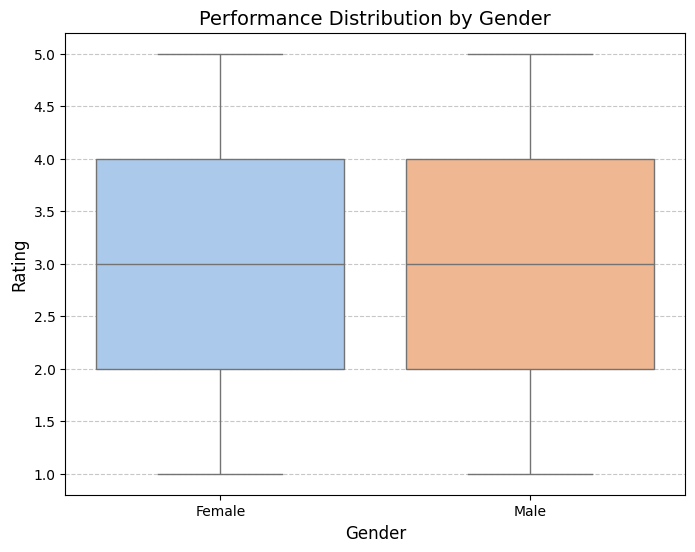

In [344]:
plt.figure(figsize=(8, 6))

# Boxplot comparando Gênero e Rating
sns.boxplot(data=df, x='gender', y='rating', hue='gender', palette='pastel')

plt.title('Performance Distribution by Gender', fontsize=14)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Rating', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

The comparative performance analysis by gender revealed no disparities in the distributed ratings, with balanced medians and interquartile ranges across both groups. This indicates that, to date, the organization's performance evaluation criteria are being applied in a gender-neutral manner.

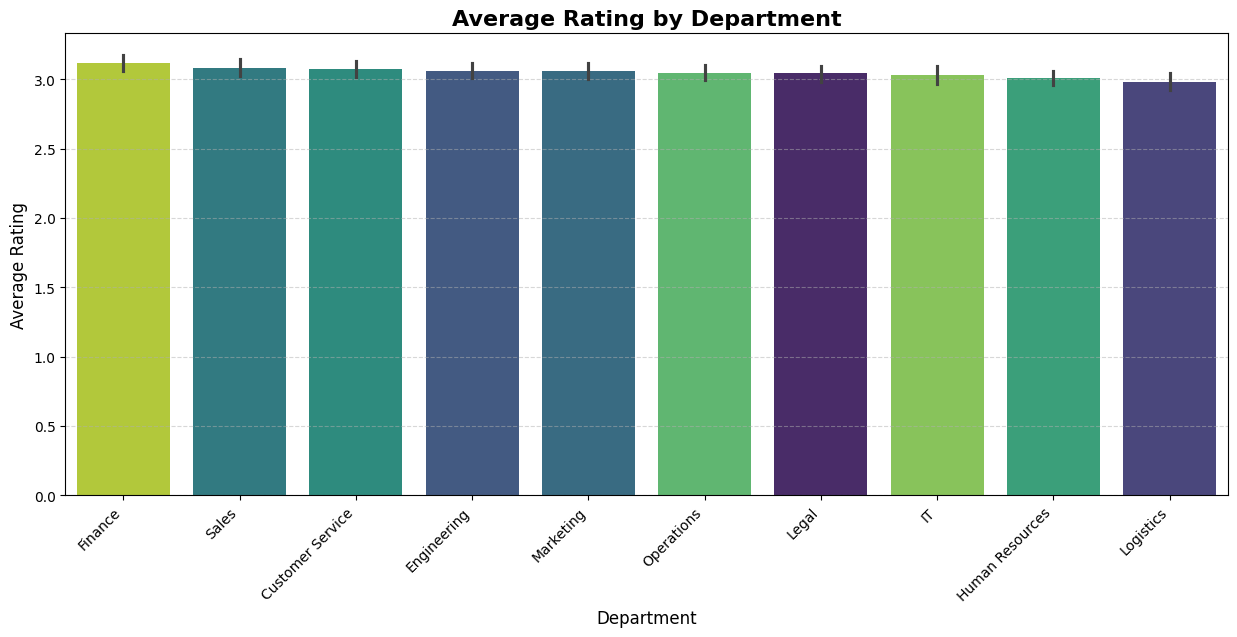

In [345]:
# Let's try to compare performance by department
plt.figure(figsize=(15, 6))

sns.barplot(data=df, x='departments', y='rating', 
            order=df.groupby('departments')['rating'].mean().sort_values(ascending=False).index,
            palette='viridis', hue='departments')
plt.title('Average Rating by Department', fontsize=16, fontweight='bold')
plt.xlabel('Department', fontsize=12)
plt.ylabel('Average Rating', fontsize=12)

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

The analysis of average performance by department shows a high level of consistency across the organization. While minor variations are observable, the overlapping error bars suggest that performance standards are uniformly applied, with no department significantly deviating from the overall corporate average.

## Recommendations & Next Steps

Based on the insights gathered from this EDA, we recommend the following actions to further optimize our performance management processes:

### 1. Targeted Investigation (Operational Risk)
* **Action:** Conduct a deep-dive investigation into the `actionID 30` process.
* **Goal:** Determine why this specific action results in a higher frequency of outliers and low-performance ratings (1.0). Is it a matter of training, process complexity, or external factors?
* **Deliverable:** A brief report on potential adjustments to the workflow or extra support for employees assigned to this specific action.

### 2. Performance Feedback Loop (Holistic Approach)
* **Action:** Move beyond tenure-based assumptions.
* **Goal:** Since performance is not correlated with seniority, focus future professional development programs on **competency-based growth** rather than years in the company.
* **Deliverable:** Align training programs with specific skill gaps identified in the low-performing segments, regardless of their tenure.

### 3. Continuous Equity Monitoring
* **Action:** Institutionalize the gender equity check.
* **Goal:** While current data shows a gender-neutral evaluation process, keeping this monitor active ensures that as the company grows, our unbiased culture remains intact.
* **Deliverable:** Include this visualization in the quarterly management review.

### 4. Departmental Support
* **Action:** Provide additional resources for the department with lower average ratings (e.g., Logistics).
* **Goal:** Ensure that lower ratings are not a symptom of process bottlenecks or lack of resources.
* **Deliverable:** A "Support Check-in" meeting with team leads to identify potential operational hurdles.